In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")
print(f"Total layers:  {model.config.n_layer}")
print(f"Total heads:   {model.config.n_head}")
print(f"Embedding dim: {model.config.n_embd}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5370.85it/s]

Ready!
Total layers:  12
Total heads:   12
Embedding dim: 768


In [8]:
layer = model.h[0]

# Conv1D mein weight shape [nx, nf] = [768, 2304]
qkv_weight = layer.attn.c_attn.weight  # [768, 2304]

d = model.config.n_embd  # 768

# Columns ke hisaab se split karo
Q_weight = qkv_weight[:, :d]      # [768, 768]
K_weight = qkv_weight[:, d:2*d]   # [768, 768]
V_weight = qkv_weight[:, 2*d:]    # [768, 768]

print(f"QKV weight shape: {qkv_weight.shape}")
print(f"Q shape: {Q_weight.shape}")
print(f"K shape: {K_weight.shape}")
print(f"V shape: {V_weight.shape}")

print(f"\nQ stats: mean={Q_weight.mean():.4f}, std={Q_weight.std():.4f}")
print(f"K stats: mean={K_weight.mean():.4f}, std={K_weight.std():.4f}")
print(f"V stats: mean={V_weight.mean():.4f}, std={V_weight.std():.4f}")

QKV weight shape: torch.Size([768, 2304])
Q shape: torch.Size([768, 768])
K shape: torch.Size([768, 768])
V shape: torch.Size([768, 768])

Q stats: mean=0.0002, std=0.2387
K stats: mean=0.0000, std=0.2433
V stats: mean=-0.0000, std=0.0581


In [9]:
q_stds, k_stds, v_stds = [], [], []

for layer_idx in range(12):
    layer      = model.h[layer_idx]
    qkv_weight = layer.attn.c_attn.weight
    
    Q = qkv_weight[:, :d]
    K = qkv_weight[:, d:2*d]
    V = qkv_weight[:, 2*d:]
    
    q_stds.append(Q.std().item())
    k_stds.append(K.std().item())
    v_stds.append(V.std().item())

print(f"{'Layer':<8} {'Q std':<10} {'K std':<10} {'V std'}")
print("-"*38)
for i in range(12):
    print(f"{i+1:<8} {q_stds[i]:<10.4f} {k_stds[i]:<10.4f} {v_stds[i]:.4f}")

Layer    Q std      K std      V std
--------------------------------------
1        0.2387     0.2433     0.0581
2        0.1510     0.1590     0.1037
3        0.1893     0.1518     0.1050
4        0.1647     0.1538     0.0977
5        0.1704     0.1575     0.1023
6        0.1413     0.1361     0.1033
7        0.1340     0.1276     0.1185
8        0.1365     0.1305     0.1195
9        0.1301     0.1244     0.1263
10       0.1230     0.1189     0.1361
11       0.1187     0.1147     0.1446
12       0.1098     0.1055     0.1623


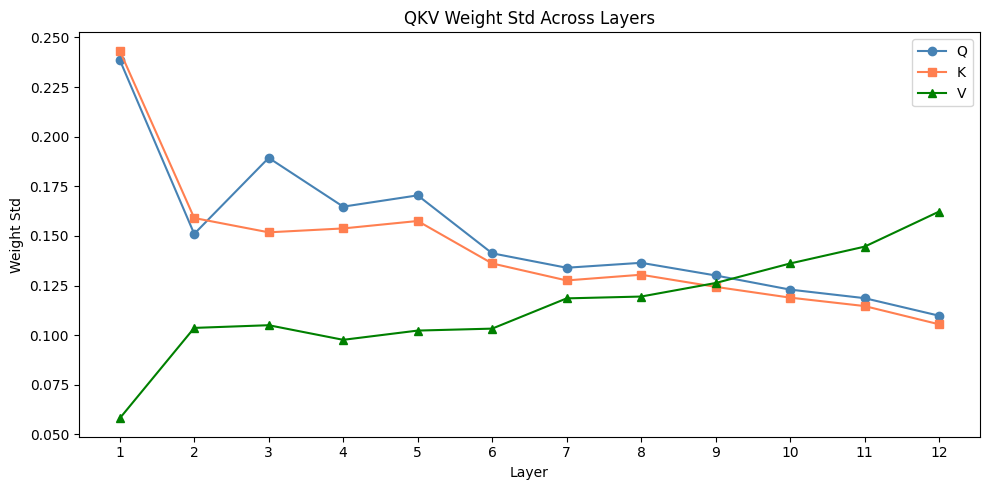

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(1, 13)
ax.plot(x, q_stds, marker='o', label="Q", color="steelblue")
ax.plot(x, k_stds, marker='s', label="K", color="coral")
ax.plot(x, v_stds, marker='^', label="V", color="green")

ax.set_xlabel("Layer")
ax.set_ylabel("Weight Std")
ax.set_title("QKV Weight Std Across Layers")
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
plt.show()

* In GPT-2:

  * **Q (Query) and K (Key) weights decrease** as layers progress.
  * **V (Value) weights increase** across layers.

* **Early layers:** V << Q, K

* **Late layers:** V >> Q, K

* The **curves intersect in the middle layers**, showing a transition point in how attention behaves.
